# CatBoost Classifier

## Objective

Train a CatBoost classifier and compare its performance with the previously developed machine learning models for UAV intrusion detection.

In [1]:
import pandas as pd
import numpy as np

from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
print("hi")

hi


In [3]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [4]:
print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (26481, 32)
Testing Shape  : (6621, 32)


## Train CatBoost Model

CatBoost is a gradient boosting algorithm that is highly effective for tabular datasets and often provides strong performance with minimal hyperparameter tuning.

In [5]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)

cat_model.fit(X_train, y_train)

0:	learn: 0.6439334	total: 185ms	remaining: 1m 32s
100:	learn: 0.7001624	total: 3.94s	remaining: 15.6s
200:	learn: 0.7280314	total: 7.62s	remaining: 11.3s
300:	learn: 0.7398890	total: 11.4s	remaining: 7.51s
400:	learn: 0.7494808	total: 15s	remaining: 3.69s
499:	learn: 0.7586572	total: 18.7s	remaining: 0us


CatBoostClassifier(depth=8, eval_metric='Accuracy', iterations=500, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

## Model Evaluation

Evaluate the trained CatBoost model using Accuracy, Precision, Recall and F1-score.

In [6]:
y_pred_cat = cat_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_cat)

print(f"CatBoost Accuracy : {accuracy:.4f}\n")

print(classification_report(y_test, y_pred_cat))

CatBoost Accuracy : 0.7377

              precision    recall  f1-score   support

           0       0.68      0.76      0.72      2334
           1       0.75      0.53      0.62      2402
           2       0.79      0.98      0.87      1885

    accuracy                           0.74      6621
   macro avg       0.74      0.76      0.74      6621
weighted avg       0.74      0.74      0.73      6621



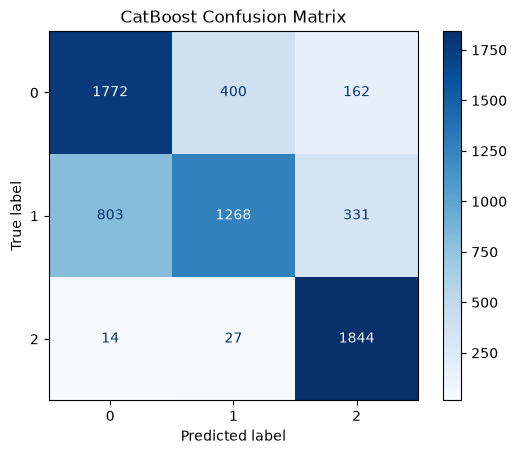

In [7]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_cat,
    cmap="Blues"
)

plt.title("CatBoost Confusion Matrix")
plt.show()

## Feature Importance

Analyze the contribution of each feature to the CatBoost model for better interpretation of the prediction process.

In [8]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
7,wlan.seq,18.944683
2,wlan.duration,14.260781
11,ip.id,8.791169
16,ip.dst,8.041570
31,time_since_last_packet,7.469875
4,wlan.ta,5.199900
3,wlan.ra,4.719996
0,frame.len,4.639997
5,wlan.da,4.592496
6,wlan.sa,4.522568


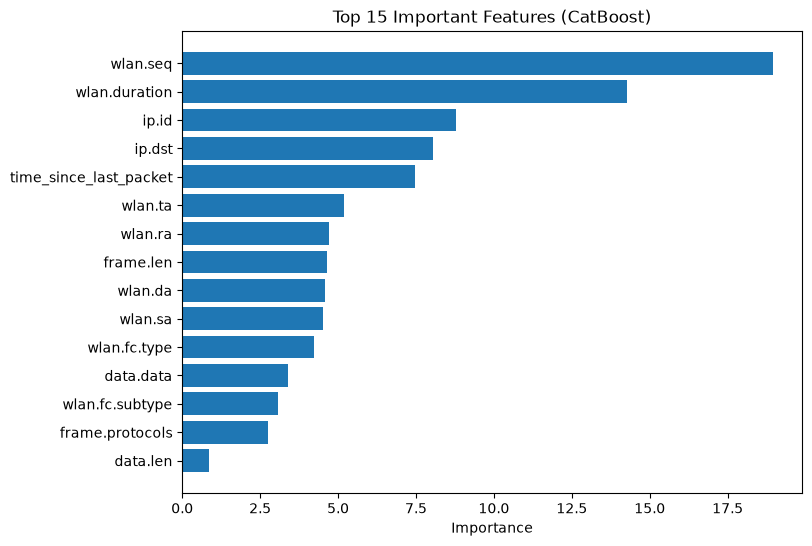

In [9]:
top_features = feature_importance.head(15)

plt.figure(figsize=(8,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.title("Top 15 Important Features (CatBoost)")
plt.gca().invert_yaxis()

plt.show()